In [1]:
import os
import sys
# Ensure project root is on sys.path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
# Imports and utilities
from typing import Dict
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from model_classes.fusion import create_fusion_model
from data_loaders.fusion_data_loader import FusionDataset, fusion_collate_fn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
# Create datasets and dataloaders
torch.manual_seed(42)

annotations_root = os.path.join(PROJECT_ROOT, 'data', 'annotations')
crops_root = os.path.join(PROJECT_ROOT, 'data', 'crops')
image_size = 128

train_ds = FusionDataset(
    annotations_root=annotations_root,
    crops_root=crops_root,
    split='train',
    image_size=image_size,
)
val_ds = FusionDataset(
    annotations_root=annotations_root,
    crops_root=crops_root,
    split='val',
    image_size=image_size,
)

num_classes = train_ds.num_classes
print(f'Dataset sizes: train={len(train_ds)}, val={len(val_ds)}')
print(f'Num classes: {num_classes}')
print(f'Class names: {train_ds.class_names()}')

Dataset sizes: train=408237, val=53392
Num classes: 18
Class names: ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']


In [4]:
# Quick smoke test - load one sample
sample = train_ds[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Graph x shape: {sample['graph'].x.shape}")
print(f"Graph edge_index shape: {sample['graph'].edge_index.shape}")
print(f"Label: {sample['label_str']} -> {sample['label']}")

Image shape: torch.Size([3, 128, 128])
Graph x shape: torch.Size([21, 2])
Graph edge_index shape: torch.Size([2, 46])
Label: call -> 0


In [5]:
# Training and evaluation helpers
def evaluate(model: nn.Module, loader: DataLoader, criterion, device) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            graph = batch['graph'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(images, graph.x, graph.edge_index, graph.batch)
            loss = criterion(logits, labels)
            
            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return {'loss': total_loss / total, 'acc': total_correct / total}

In [6]:
# Hyperparameters
final_models_dir = os.path.join(PROJECT_ROOT, 'final_models')
os.makedirs(final_models_dir, exist_ok=True)

# Model config
gnn_hidden_channels = 64
gnn_num_layers = 3
gnn_dropout = 0.1
resnet_dropout = 0.2
resnet_pretrained = True  # Use ImageNet pretrained weights
fusion_hidden = 256
fusion_dropout = 0.3
freeze_backbones = False  # Set True to train only fusion head

# Training config
lr = 1e-4  # Lower LR since we're using pretrained ResNet
batch_size = 32
max_epochs = 8
eval_interval = 500

# Optional: load pretrained backbone checkpoints
gnn_checkpoint = os.path.join(final_models_dir, 'gnn.pth')
resnet_checkpoint = os.path.join(final_models_dir, 'resnet34.pth')
load_pretrained_backbones = True  # Set to True to load your trained backbones

In [7]:
# Build model
model = create_fusion_model(
    num_classes=num_classes,
    gnn_hidden_channels=gnn_hidden_channels,
    gnn_num_layers=gnn_num_layers,
    gnn_dropout=gnn_dropout,
    resnet_dropout=resnet_dropout,
    resnet_pretrained=resnet_pretrained,
    fusion_hidden=fusion_hidden,
    fusion_dropout=fusion_dropout,
    freeze_backbones=freeze_backbones,
)

# Optionally load pretrained backbone weights
if load_pretrained_backbones:
    if os.path.exists(gnn_checkpoint):
        model.load_pretrained_backbones(gnn_checkpoint=gnn_checkpoint)
    else:
        print(f'GNN checkpoint not found: {gnn_checkpoint}')
    
    if os.path.exists(resnet_checkpoint):
        model.load_pretrained_backbones(resnet_checkpoint=resnet_checkpoint)
    else:
        print(f'ResNet checkpoint not found: {resnet_checkpoint}')

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loaded GNN weights from /home/quiet98k/Code/Fall25/hand-gestures-classifier/final_models/gnn.pth
Loaded ResNet weights from /home/quiet98k/Code/Fall25/hand-gestures-classifier/final_models/resnet34.pth
Total parameters: 21,491,958
Trainable parameters: 21,491,958


In [8]:
# Create dataloaders and optimizer
train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, 
    collate_fn=fusion_collate_fn, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False,
    collate_fn=fusion_collate_fn, drop_last=False
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 12758, Val batches: 1669


In [9]:
# Training loop with intra-epoch evaluation
best_val_acc = 0.0
best_state = None
history = {'step': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
global_step = 0

for epoch in range(1, max_epochs + 1):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0
    
    for batch_idx, batch in enumerate(train_loader, start=1):
        images = batch['image'].to(device)
        graph = batch['graph'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits = model(images, graph.x, graph.edge_index, graph.batch)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        bsz = labels.size(0)
        epoch_loss += loss.item() * bsz
        preds = logits.argmax(dim=1)
        epoch_correct += (preds == labels).sum().item()
        epoch_total += bsz
        global_step += 1
        
        # Intra-epoch evaluation
        if global_step % eval_interval == 0:
            train_loss = epoch_loss / epoch_total
            train_acc = epoch_correct / epoch_total
            va = evaluate(model, val_loader, criterion, device)
            history['step'].append(global_step)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(va['loss'])
            history['val_acc'].append(va['acc'])
            print(f'Step {global_step} (Epoch {epoch}) | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={va["loss"]:.4f} val_acc={va["acc"]:.4f}')
            if va['acc'] > best_val_acc:
                best_val_acc = va['acc']
                best_state = {'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'epoch': epoch, 'step': global_step}
            model.train()
    
    # End of epoch evaluation
    train_loss = epoch_loss / epoch_total
    train_acc = epoch_correct / epoch_total
    va = evaluate(model, val_loader, criterion, device)
    print(f'Epoch {epoch}/{max_epochs} END | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={va["loss"]:.4f} val_acc={va["acc"]:.4f}')
    if va['acc'] > best_val_acc:
        best_val_acc = va['acc']
        best_state = {'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'epoch': epoch, 'step': global_step}

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Step 500 (Epoch 1) | train_loss=0.8166 train_acc=0.9442 | val_loss=0.1651 val_acc=0.9973
Step 1000 (Epoch 1) | train_loss=0.4938 train_acc=0.9713 | val_loss=0.0526 val_acc=0.9971
Step 1500 (Epoch 1) | train_loss=0.3547 train_acc=0.9805 | val_loss=0.0299 val_acc=0.9969
Step 2000 (Epoch 1) | train_loss=0.2772 train_acc=0.9850 | val_loss=0.0221 val_acc=0.9968
Step 2500 (Epoch 1) | train_loss=0.2278 train_acc=0.9876 | val_loss=0.0254 val_acc=0.9952
Step 3000 (Epoch 1) | train_loss=0.1937 train_acc=0.9894 | val_loss=0.0188 val_acc=0.9966
Step 3500 (Epoch 1) | train_loss=0.1692 train_acc=0.9905 | val_loss=0.0241 val_acc=0.9953
Step 4000 (Epoch 1) | train_loss=0.1497 train_acc=0.9915 | val_loss=0.0205 val_acc=0.9961
Step 4500 (Epoch 1) | train_loss=0.1347 train_acc=0.9922 | val_loss=0.0185 val_acc=0.9963
Step 5000 (Epoch 1) | train_loss=0.1229 train_acc=0.9928 | val_loss=0.0237 val_acc=0.9958
Step 5500 (Epoch 1) | train_loss=0.1130 train_acc=0.9932 | val_loss=0.0233 val_acc=0.9956
Step 6000 (

In [10]:
# Save best model
out_path = os.path.join(final_models_dir, 'fusion.pth')
if best_state is not None:
    torch.save({
        'config': {
            'gnn_hidden_channels': gnn_hidden_channels,
            'gnn_num_layers': gnn_num_layers,
            'gnn_dropout': gnn_dropout,
            'resnet_dropout': resnet_dropout,
            'resnet_pretrained': resnet_pretrained,
            'fusion_hidden': fusion_hidden,
            'fusion_dropout': fusion_dropout,
            'freeze_backbones': freeze_backbones,
            'lr': lr,
            'batch_size': batch_size,
            'max_epochs': max_epochs,
            'image_size': image_size,
        },
        'best_val_acc': best_val_acc,
        'state': best_state,
    }, out_path)
    print(f'Saved best model to {out_path}')
    
    # Update combined metadata JSON
    meta_entry = {
        'model_type': 'fusion',
        'data_type': 'fusion',  # Both graph and RGB
        'num_classes': num_classes,
        'gnn_hidden_channels': gnn_hidden_channels,
        'gnn_num_layers': gnn_num_layers,
        'gnn_dropout': gnn_dropout,
        'resnet_dropout': resnet_dropout,
        'fusion_hidden': fusion_hidden,
        'fusion_dropout': fusion_dropout,
        'image_size': image_size,
        'training': {'lr': lr, 'batch_size': batch_size, 'max_epochs': max_epochs},
        'best_val_acc': best_val_acc,
        'checkpoint_path': out_path,
    }
    combined_meta_path = os.path.join(final_models_dir, 'models_metadata.json')
    try:
        import json
        combined = {}
        if os.path.exists(combined_meta_path):
            with open(combined_meta_path, 'r') as cf:
                try:
                    combined = json.load(cf)
                except Exception:
                    combined = {}
        combined['fusion'] = meta_entry
        with open(combined_meta_path, 'w') as cf:
            json.dump(combined, cf, indent=2)
        print(f'Updated {combined_meta_path}')
    except Exception as e:
        print(f'Warning: failed to write metadata: {e}')

# Build best record for plotting
best = {
    'config': {
        'gnn_hidden_channels': gnn_hidden_channels,
        'gnn_num_layers': gnn_num_layers,
        'fusion_hidden': fusion_hidden,
        'lr': lr,
        'batch_size': batch_size,
    },
    'best_val_acc': best_val_acc,
    'path': out_path,
    'history': history,
}

Saved best model to /home/quiet98k/Code/Fall25/hand-gestures-classifier/final_models/fusion.pth
Updated /home/quiet98k/Code/Fall25/hand-gestures-classifier/final_models/models_metadata.json


In [11]:
# Load best model and run a quick inference check
print(f"Best config: {best['config']} val_acc={best['best_val_acc']:.4f}")

ckpt = torch.load(best['path'], map_location=device, weights_only=False)
cfg = ckpt['config']

model_check = create_fusion_model(
    num_classes=num_classes,
    gnn_hidden_channels=cfg['gnn_hidden_channels'],
    gnn_num_layers=cfg['gnn_num_layers'],
    fusion_hidden=cfg['fusion_hidden'],
    resnet_pretrained=False,  # Don't load pretrained, we have checkpoint
)
model_check.load_state_dict(ckpt['state']['model_state'])
model_check = model_check.to(device).eval()

# Run inference on a small batch
batch = next(iter(val_loader))
images = batch['image'].to(device)
graph = batch['graph'].to(device)
labels = batch['label']

with torch.no_grad():
    logits = model_check(images, graph.x, graph.edge_index, graph.batch)
    preds = logits.argmax(dim=1).cpu()

print(f"Sample preds: {preds[:10].tolist()}")
print(f"Sample labels: {labels[:10].tolist()}")

Best config: {'gnn_hidden_channels': 64, 'gnn_num_layers': 3, 'fusion_hidden': 256, 'lr': 0.0001, 'batch_size': 32} val_acc=0.9973
Sample preds: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


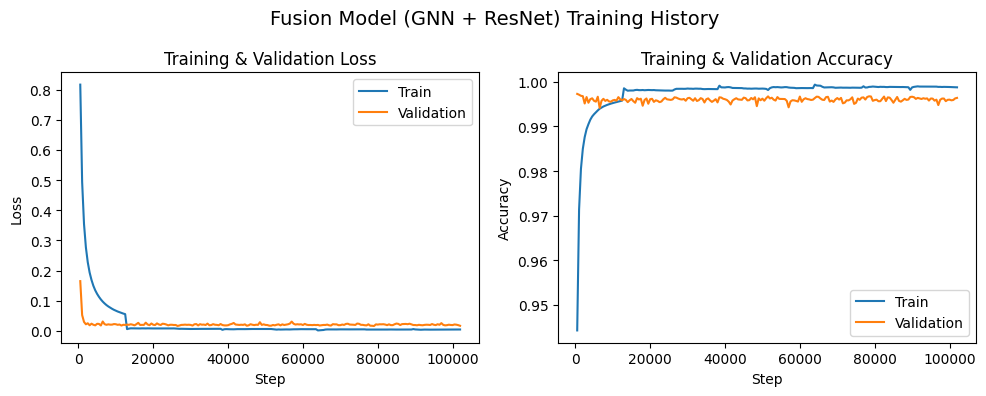

Saved plot to /home/quiet98k/Code/Fall25/hand-gestures-classifier/graphs/fusion_training_history.png


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 577, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
  File "/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/quiet98k/Code/Fall25/hand-gestur

In [ ]:
# Plot training/validation history
import matplotlib.pyplot as plt

# Ensure graphs directory exists
graphs_dir = os.path.join(PROJECT_ROOT, 'graphs')
os.makedirs(graphs_dir, exist_ok=True)

hist = best.get('history')
if hist is None or not hist.get('step'):
    print('No history available')
else:
    steps = hist['step']
    fig = plt.figure(figsize=(10, 4))
    fig.suptitle('Fusion Model (GNN + ResNet) Training History', fontsize=14)
    
    plt.subplot(1, 2, 1)
    plt.plot(steps, hist['train_loss'], label='Train')
    plt.plot(steps, hist['val_loss'], label='Validation')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(steps, hist['train_acc'], label='Train')
    plt.plot(steps, hist['val_acc'], label='Validation')
    plt.xlabel('Step')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(graphs_dir, 'fusion_training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved plot to {graphs_dir}/fusion_training_history.png')